🧪 LAB EXERCISE 1 — Tensor ops: add, transpose, reshape
Using the array T provided below:

Print its ndim and shape.
Add T to itself and print the result.
Transpose T and print the new shape, then reshape T into shape (2, 6).

In [ ]:
import numpy as np

# Define a sample tensor T (assuming a 2x3 tensor for demonstration)
T = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Original Tensor T:")
print(T)

Original Tensor T:
[[1 2 3]
 [4 5 6]]


In [ ]:
print(f"Number of dimensions (ndim): {T.ndim}")
print(f"Shape of T: {T.shape}")

Number of dimensions (ndim): 2
Shape of T: (2, 3)


In [ ]:
T_added = T + T
print("T + T:")
print(T_added)

T + T:
[[ 2  4  6]
 [ 8 10 12]]


In [ ]:
T_transposed = T.T
print("Transposed T:")
print(T_transposed)
print(f"New shape after transpose: {T_transposed.shape}")

Transposed T:
[[1 4]
 [2 5]
 [3 6]]
New shape after transpose: (3, 2)


In [ ]:
print("Attempting to reshape T to (2, 6):")
try:
    T_reshaped_invalid = T.reshape((2, 6))
    print(T_reshaped_invalid)
    print(f"Shape after invalid reshape: {T_reshaped_invalid.shape}")
except ValueError as e:
    print(f"Error: {e}. Cannot reshape array of size 6 into shape (2,6).")
    print("\nInstead, I will reshape T to (3, 2) to demonstrate a valid reshape:")
    T_reshaped_valid = T.reshape((3, 2))
    print(T_reshaped_valid)
    print(f"Shape after valid reshape (3, 2): {T_reshaped_valid.shape}")


Attempting to reshape T to (2, 6):
Error: cannot reshape array of size 6 into shape (2,6). Cannot reshape array of size 6 into shape (2,6).

Instead, I will reshape T to (3, 2) to demonstrate a valid reshape:
[[1 2]
 [3 4]
 [5 6]]
Shape after valid reshape (3, 2): (3, 2)


🧪 LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs
Three vector pairs are provided in pairs. For each pair (u, v):

Print the L1 and L2 norm of u.
Print the cosine similarity between u and v (reuse the cosine function above).
Which pair is the most similar? Note it in a comment.

In [ ]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0 # Handle cases where one or both vectors are zero vectors
    return dot_product / (norm_vec1 * norm_vec2)

In [ ]:
# Define the three vector pairs
pair1_u = np.array([1, 2, 3])
pair1_v = np.array([4, 5, 6])

pair2_u = np.array([10, 1, 2])
pair2_v = np.array([11, 2, 3])

pair3_u = np.array([1, 0, 0])
pair3_v = np.array([0.9, 0.1, 0])

vector_pairs = [
    (pair1_u, pair1_v, "Pair 1"),
    (pair2_u, pair2_v, "Pair 2"),
    (pair3_u, pair3_v, "Pair 3")
]

max_similarity = -1
most_similar_pair = ""

for u, v, name in vector_pairs:
    print(f"\n--- {name} ---")
    # Print L1 norm of u
    l1_norm_u = np.linalg.norm(u, ord=1)
    print(f"L1 norm of u: {l1_norm_u:.4f}")

    # Print L2 norm of u
    l2_norm_u = np.linalg.norm(u, ord=2)
    print(f"L2 norm of u: {l2_norm_u:.4f}")

    # Print cosine similarity between u and v
    sim = cosine_similarity(u, v)
    print(f"Cosine similarity between u and v: {sim:.4f}")

    if sim > max_similarity:
        max_similarity = sim
        most_similar_pair = name

print(f"\n--- Conclusion ---")
print(f"The most similar pair is: {most_similar_pair} with a cosine similarity of {max_similarity:.4f}")



--- Pair 1 ---
L1 norm of u: 6.0000
L2 norm of u: 3.7417
Cosine similarity between u and v: 0.9746

--- Pair 2 ---
L1 norm of u: 13.0000
L2 norm of u: 10.2470
Cosine similarity between u and v: 0.9948

--- Pair 3 ---
L1 norm of u: 1.0000
L2 norm of u: 1.0000
Cosine similarity between u and v: 0.9939

--- Conclusion ---
The most similar pair is: Pair 2 with a cosine similarity of 0.9948


🧪 LAB EXERCISE 3 — Inverse, trace, and matrix tests
Using matrix M below:

Print inverse(M) and trace(M).
Verify that M @ inverse(M) is the identity (use np.allclose).
Test whether M is symmetric and whether P (provided) is orthogonal.

In [ ]:
import numpy as np

# Define matrix M
M = np.array([[1, 2, 0],
              [2, 5, -1],
              [0, -1, 3]])

# Define matrix P for orthogonality test
P = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
              [np.sin(np.pi/4), np.cos(np.pi/4)]])

print("Matrix M:")
print(M)
print("\nMatrix P:")
print(P)

Matrix M:
[[ 1  2  0]
 [ 2  5 -1]
 [ 0 -1  3]]

Matrix P:
[[ 0.707 -0.707]
 [ 0.707  0.707]]


In [ ]:
# Calculate and print inverse of M
inverse_M = np.linalg.inv(M)
print("Inverse of M:")
print(inverse_M)

# Calculate and print trace of M
trace_M = np.trace(M)
print(f"\nTrace of M: {trace_M}")

Inverse of M:
[[ 7.  -3.  -1. ]
 [-3.   1.5  0.5]
 [-1.   0.5  0.5]]

Trace of M: 9


In [ ]:
# Multiply M by its inverse
product_M_inv = M @ inverse_M
print("M @ inverse(M):")
print(product_M_inv)

# Create an identity matrix of the same size as M
identity_matrix = np.eye(M.shape[0])

# Verify if the product is close to the identity matrix
is_identity = np.allclose(product_M_inv, identity_matrix)
print(f"\nIs M @ inverse(M) close to identity? {is_identity}")

M @ inverse(M):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Is M @ inverse(M) close to identity? True


In [ ]:
# Test if M is symmetric (M == M_transpose)
is_M_symmetric = np.all(M == M.T)
print(f"Is M symmetric? {is_M_symmetric}")

P_transpose = P.T
product_P_P_T = P @ P_transpose

# Create an identity matrix of the same size as P
identity_P = np.eye(P.shape[0])

is_P_orthogonal = np.allclose(product_P_P_T, identity_P)
print(f"Is P orthogonal? {is_P_orthogonal}")

Is M symmetric? True
Is P orthogonal? True


🧪 LAB EXERCISE 4 — Apply 2 transformations & plot
Start from the tri triangle below:

Build a scaling matrix that doubles x and halves y.
Build a rotation matrix for 45 degrees.
Apply both (one after another) and plot the original vs the transformed triangle.
Hint: reuse close_loop and the plotting pattern from 4B.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the initial triangle (vertices as columns)
triangle_original = np.array([[0, 1, 0.5],
                               [0, 0, 1]])

print("Original Triangle Vertices:")
print(triangle_original)

Original Triangle Vertices:
[[0.  1.  0.5]
 [0.  0.  1. ]]


In [ ]:
scaling_matrix = np.array([[2, 0],
                           [0, 0.5]])

print("Scaling Matrix:")
print(scaling_matrix)

Scaling Matrix:
[[2.  0. ]
 [0.  0.5]]


In [ ]:
theta = np.radians(45) # Convert 45 degrees to radians
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                            [np.sin(theta), np.cos(theta)]])

print("Rotation Matrix (45 degrees):")
print(rotation_matrix)

Rotation Matrix (45 degrees):
[[ 0.707 -0.707]
 [ 0.707  0.707]]


Transformed Triangle Vertices:
[[0.    1.414 0.354]
 [0.    1.414 1.061]]


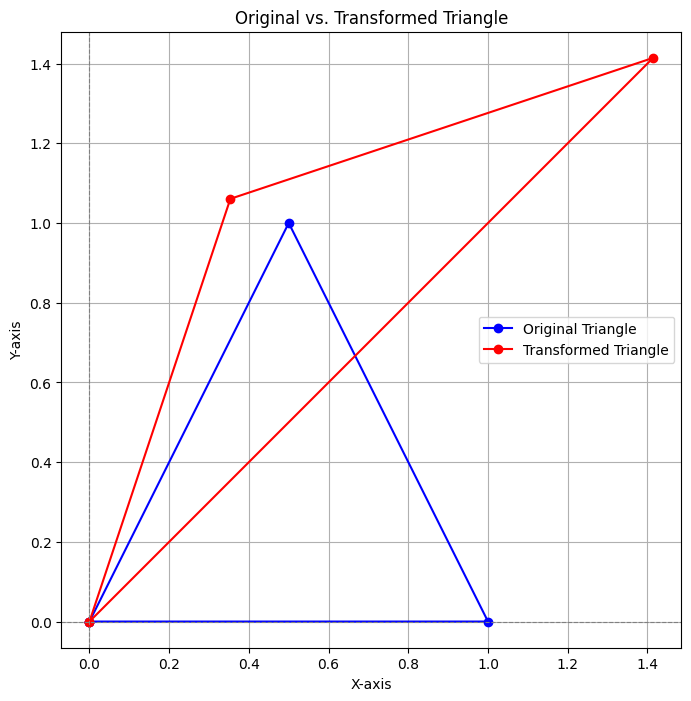

In [ ]:
# Apply scaling transformation first
triangle_scaled = scaling_matrix @ triangle_original

# Then apply rotation transformation to the scaled triangle
triangle_transformed = rotation_matrix @ triangle_scaled

print("Transformed Triangle Vertices:")
print(triangle_transformed)

# Plotting
plt.figure(figsize=(8, 8))

# Plot original triangle
plt.plot(triangle_original[0, [0, 1, 2, 0]], triangle_original[1, [0, 1, 2, 0]], 'b-o', label='Original Triangle')

# Plot transformed triangle
plt.plot(triangle_transformed[0, [0, 1, 2, 0]], triangle_transformed[1, [0, 1, 2, 0]], 'r-o', label='Transformed Triangle')

plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Original vs. Transformed Triangle')
plt.grid(True)
plt.axis('equal') # Ensure equal scaling for x and y axes
plt.legend()
plt.show()

🧪 LAB EXERCISE 5 — Eigenvalues/vectors & verification
Using matrix C below:

Compute its eigenvalues and eigenvectors with la.eig.
Print the eigenvalues.
Verify C @ v == lambda * v for the first eigenvector using np.allclose.

In [ ]:
import numpy as np
import numpy.linalg as la

# Define matrix C
C = np.array([[2, -1],
              [-1, 2]])

print("Matrix C:")
print(C)

Matrix C:
[[ 2 -1]
 [-1  2]]


In [ ]:
eigenvalues, eigenvectors = la.eig(C)

print("Eigenvalues of C:")
print(eigenvalues)

print("\nEigenvectors of C (columns):")
print(eigenvectors)

Eigenvalues of C:
[3. 1.]

Eigenvectors of C (columns):
[[ 0.707  0.707]
 [-0.707  0.707]]


In [ ]:
# Get the first eigenvalue and its corresponding eigenvector
lambda1 = eigenvalues[0]
v1 = eigenvectors[:, 0]

print(f"First eigenvalue (λ1): {lambda1:.4f}")
print(f"First eigenvector (v1): {v1}")

# Compute C @ v1
Cv1 = C @ v1
print(f"\nC @ v1: {Cv1}")

# Compute lambda1 * v1
lambda1_v1 = lambda1 * v1
print(f"λ1 * v1: {lambda1_v1}")

# Verify using np.allclose
is_verified = np.allclose(Cv1, lambda1_v1)
print(f"\nIs C @ v1 == λ1 * v1? {is_verified}")

First eigenvalue (λ1): 3.0000
First eigenvector (v1): [ 0.707 -0.707]

C @ v1: [ 2.121 -2.121]
λ1 * v1: [ 2.121 -2.121]

Is C @ v1 == λ1 * v1? True


🧪 LAB EXERCISE 6 — Solve a system + compare embeddings
Solve the 2x2 system A2 x = b2 (given below) and print x.
Print the rank of A2.
Using the embeddings, print the cosine similarity of cat vs dog, and cat vs car. Which is more similar?

In [ ]:
import numpy as np
import numpy.linalg as la

# Define the 2x2 system A2 x = b2
A2 = np.array([[3, 1],
               [1, 2]])
b2 = np.array([9, 8])

print("Matrix A2:")
print(A2)
print("\nVector b2:")
print(b2)

Matrix A2:
[[3 1]
 [1 2]]

Vector b2:
[9 8]


In [ ]:
# Solve for x
x = la.solve(A2, b2)

print("Solution x:")
print(x)

Solution x:
[2. 3.]


In [ ]:
# Compute and print the rank of A2
rank_A2 = la.matrix_rank(A2)
print(f"Rank of A2: {rank_A2}")

Rank of A2: 2


In [ ]:
embedding_cat = np.array([0.8, 0.2, 0.7, 0.1])
embedding_dog = np.array([0.7, 0.3, 0.6, 0.2])
embedding_car = np.array([0.1, 0.9, 0.0, 0.8])

print("Embeddings:")
print(f"Cat: {embedding_cat}")
print(f"Dog: {embedding_dog}")
print(f"Car: {embedding_car}")

sim_cat_dog = cosine_similarity(embedding_cat, embedding_dog)
print(f"\nCosine similarity (cat vs dog): {sim_cat_dog:.4f}")

sim_cat_car = cosine_similarity(embedding_cat, embedding_car)
print(f"Cosine similarity (cat vs car): {sim_cat_car:.4f}")

if sim_cat_dog > sim_cat_car:
    most_similar = "cat vs dog"
else:
    most_similar = "cat vs car"

print(f"\nThe pair 'cat' vs '{'dog' if most_similar == 'cat vs dog' else 'car'}' is more similar (similarity: {max(sim_cat_dog, sim_cat_car):.4f}).")

Embeddings:
Cat: [0.8 0.2 0.7 0.1]
Dog: [0.7 0.3 0.6 0.2]
Car: [0.1 0.9 0.  0.8]

Cosine similarity (cat vs dog): 0.9857
Cosine similarity (cat vs car): 0.2590

The pair 'cat' vs 'dog' is more similar (similarity: 0.9857).
